# Anatomy of engine divergence

**Docker image**: `ml4t`

## Purpose
Two backtesting engines handed the same signals will not return the same track record, and the
reasons are rarely in the signal. They are decisions about execution - which side of a rebalance
is processed first, whether a position can be a fraction of a share, whether cash is reserved to
pay the commission - that most libraries make for you and few of them announce.

`BacktestConfig` exposes each of those as a named field, so this notebook can hold one strategy
fixed and change exactly one of them at a time. That turns "the two engines disagree" into a
measurement: this much came from share rounding, this much from the cash buffer, this much from
how the two interact, and this much is not explained by any of them.

One of the four is a null result, and it is worth as much as the other three: a setting the
configuration lets you change can still be unreachable, because something upstream of the broker
has already decided the thing it controls.

## Learning objectives

- Build one controlled reference configuration in which every execution field is named, so that a
  later change to a library default cannot move the experiment without you noticing.
- Change one execution field at a time and measure what it is worth, in dollars of ending value
  and in the number of trades that actually filled.
- Check whether a setting reached the code path you think it reached, before crediting a result
  to it.
- Read a decomposition that does not add up: measure the effects together as well as separately,
  and treat the residual as a quantity rather than an error.

## Book reference
Chapter 16, Section 16.3 (backtesting engine comparison).

## Prerequisites

- [`06_linear`](../case_studies/etfs/06_linear.ipynb), which produces the ETF prediction
  artifacts this notebook reads. Nothing here re-fits a model; the signals arrive precomputed and
  are held fixed throughout.
- `06_framework_parity`, which shows the same two-implementation gap without decomposing it.

In [1]:
"""Anatomy of Engine Divergence - how execution mechanics change backtest results."""

import copy
from datetime import datetime

import matplotlib.pyplot as plt
import polars as pl
from ml4t.backtest import BacktestConfig, DataFeed, Engine
from ml4t.backtest.config import (
    CommissionType,
    ExecutionMode,
    ExecutionPrice,
    FillOrdering,
    RebalanceMode,
    ShareType,
    SlippageType,
)
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from validation.adapters.ml4t_adapter import (
    PrecomputedWeightStrategy,
    _align_prices_to_weight_window,
    _convert_result,
    _filter_late_assets,
)
from validation.adapters.vectorbt_adapter import run_vectorbt
from validation.weights import load_case_study_data

from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
CASE_STUDY = "etfs"
LABEL = "fwd_ret_21d"
INITIAL_CASH = 1_000_000

## 1. Load the shared signal

The predictions come from the ETF linear-model pipeline's validation window and are read, never
recomputed. Before any portfolio is formed, the tradable universe is fixed to the assets that
already had price history on the first signal date, so that no configuration below gains or loses
an asset partway through and no difference between runs can be traced to the universe.

The settings this notebook binds:

**Case study and label.** Which prediction artifact to read. The choice affects the level of
every number below and none of the comparisons, because every configuration reads the same one.

**Starting capital.** The one setting that changes what the comparisons conclude. Whole-share
rounding is a fixed number of dollars per trade and a shrinking fraction of a growing account, so
the size of the account decides whether integer sizing is a rounding detail or a real constraint.

In [3]:
prices, signals, initial_weights, meta = load_case_study_data(CASE_STUDY, LABEL)
cost_rate = meta["cost_bps"] / 10_000

if initial_weights.empty:
    raise RuntimeError(
        "No validation weights were produced for this case study. "
        "Run the prerequisite prediction pipeline before executing this notebook."
    )

print(f"Case Study: {meta['case_study']}")
print(f"Label: {meta['label']} (pre-computed linear validation predictions)")
print(f"Signal universe: {meta['n_assets']} assets, {meta['n_signal_dates']} signal dates")
print(f"Cost: {meta['cost_bps']} bps ({cost_rate:.4f})")
print(f"Period: {initial_weights.index[0].date()} to {initial_weights.index[-1].date()}")

Case Study: etfs
Label: fwd_ret_21d (pre-computed linear validation predictions)
Signal universe: 99 assets, 1995 signal dates
Cost: 10 bps (0.0010)
Period: 2015-12-28 to 2023-11-29


### Turn predictions into target weights

Ranking a cross-section needs a rule for what to do when the ranking does not separate the
assets, and leaving that rule implicit is how two runs of the same code end up holding different
portfolios. Two cases have to be decided.

A cross-section in which every prediction is identical carries no ranking at all. Sorting it
returns whatever order the rows happened to arrive in, so any top slice taken from it is an
artifact of the file. This notebook holds the whole tradable universe equally weighted on those
dates instead, and counts them, so the reader can see how much of the sample they are.

A cross-section with a tie straddling the quintile cutoff has a genuine ranking and an ambiguous
boundary. Sorting by `symbol` ascending as the second key resolves it the same way every run.

In [4]:
def select_cross_section(cross_section, tradable_assets):
    """Select one cross-section using the disclosed deterministic tie policy."""
    ranked = cross_section.sort(["prediction", "symbol"], descending=[True, False])
    top_n = max(1, ranked.height // 5)
    if ranked["prediction"].n_unique() == 1:
        return tradable_assets, True, False

    cutoff = ranked["prediction"][top_n - 1]
    above = ranked.filter(pl.col("prediction") > cutoff).height
    at_or_above = ranked.filter(pl.col("prediction") >= cutoff).height
    cutoff_tie = above < top_n < at_or_above
    return ranked["symbol"].head(top_n).to_list(), False, cutoff_tie

In [5]:
def form_tie_aware_weights(signals, tradable_assets, min_assets):
    """Apply a permutation-invariant cross-sectional selection policy."""
    selections = []
    all_equal_dates = 0
    cutoff_tie_dates = 0
    for timestamp in signals["timestamp"].unique().sort():
        cross_section = signals.filter(pl.col("timestamp") == timestamp)
        if cross_section.height < min_assets:
            continue
        selected, all_equal, cutoff_tie = select_cross_section(cross_section, tradable_assets)
        all_equal_dates += int(all_equal)
        cutoff_tie_dates += int(cutoff_tie)
        weight = 1.0 / len(selected)
        selections.append(
            pl.DataFrame(
                {"timestamp": [timestamp] * len(selected), "symbol": selected}
            ).with_columns(pl.lit(weight).alias("weight"))
        )
    selected_long = pl.concat(selections)
    weights = selected_long.pivot(on="symbol", index="timestamp", values="weight").sort("timestamp")
    missing = [symbol for symbol in tradable_assets if symbol not in weights.columns]
    weights = weights.with_columns(*(pl.lit(0.0).alias(symbol) for symbol in missing))
    weights_pd = weights.select("timestamp", *tradable_assets).to_pandas().set_index("timestamp")
    return weights_pd.fillna(0.0), all_equal_dates, cutoff_tie_dates

`build_tradable_weights` fixes that universe before the policy is applied, then removes the
floating-point residue left by dividing one by an asset count. The residue is a few parts in
10^16 and would be irrelevant anywhere else, but a row that sums to slightly under one is a row
where the engine holds slightly less than the target, and comparing engines on differences of a
few basis points means that residue has to go. It is pushed onto one held asset, chosen by sorted
symbol so the choice is the same on every run.

In [6]:
def build_tradable_weights(prices, signals, seed_weights, min_assets):
    """Fix the tradable universe before portfolio formation and normalize each row."""
    prices_f, seed_weights_f = _filter_late_assets(prices, seed_weights)
    tradable_assets = sorted(prices_f["symbol"].unique().to_list())
    signals_f = signals.filter(pl.col("symbol").is_in(tradable_assets))
    weights_f, all_equal_dates, cutoff_tie_dates = form_tie_aware_weights(
        signals_f, tradable_assets, min_assets
    )
    weights_f = weights_f.div(weights_f.sum(axis=1), axis=0)

    residual = 1.0 - weights_f.sum(axis=1)
    for timestamp, adjustment in residual.items():
        anchor = weights_f.loc[timestamp][weights_f.loc[timestamp] > 0].index[0]
        weights_f.at[timestamp, anchor] += adjustment

    removed_assets = sorted(set(seed_weights.columns) - set(seed_weights_f.columns))
    prices_f, weights_f = _align_prices_to_weight_window(prices_f, weights_f)
    tie_policy = {"all_equal": all_equal_dates, "cutoff_ties": cutoff_tie_dates}
    return prices_f, weights_f, removed_assets, tie_policy

The check below is executable rather than asserted in prose: every baseline row has to sum to
exactly one, and the run stops if any does not. Read the printed all-equal count as well - those
are dates on which the model separated nothing and the portfolio is the whole universe, so a
large share of them would mean the comparisons below are partly a comparison of equal-weight
rebalancing.

In [7]:
prices_f, weights_f, removed_assets, tie_policy = build_tradable_weights(
    prices, signals, initial_weights, meta["min_assets"]
)
baseline_weight_sums = weights_f.sum(axis=1)
if not baseline_weight_sums.eq(1.0).all():
    raise RuntimeError("Tradable-universe target weights are not fully invested")

print(f"Comparison universe: {weights_f.shape[1]} assets")
print(f"Excluded late starters: {', '.join(removed_assets) if removed_assets else 'none'}")
print(f"Executable window: {weights_f.index[0].date()} to {weights_f.index[-1].date()}")
print(f"All-equal dates using the full universe: {tie_policy['all_equal']}")
print(f"Cutoff ties resolved by symbol: {tie_policy['cutoff_ties']}")
print(
    f"Baseline allocation range: {baseline_weight_sums.min():.6f} "
    f"to {baseline_weight_sums.max():.6f}"
)

Comparison universe: 99 assets
Excluded late starters: XLC
Executable window: 2015-12-28 to 2023-11-29
All-equal dates using the full universe: 252
Cutoff ties resolved by symbol: 0
Baseline allocation range: 1.000000 to 1.000000


`run_with_config` wires a `BacktestConfig` through the precomputed-weights
strategy and returns a standardized result; downstream cells call it with
different configs to isolate one execution mechanic at a time.

In [8]:
def run_with_config(config, target_weights=weights_f):
    """Run ml4t-backtest with explicit BacktestConfig and return BacktestResult."""
    allow_frac = config.share_type == ShareType.FRACTIONAL
    rebalance_cfg = RebalanceConfig(
        allow_fractional=allow_frac,
        min_trade_value=0.0,
        min_weight_change=0.0,
        rebalance_mode=config.rebalance_mode,
    )

    weight_dict: dict[datetime, dict[str, float]] = {}
    for ts in target_weights.index:
        ts_dt = ts.to_pydatetime() if hasattr(ts, "to_pydatetime") else ts
        row = target_weights.loc[ts]
        w = {c: float(row[c]) for c in target_weights.columns if row[c] > 0}
        if w:
            weight_dict[ts_dt] = w

    executor = TargetWeightExecutor(config=rebalance_cfg)
    strategy = PrecomputedWeightStrategy(weight_dict, executor)
    feed = DataFeed(prices_df=prices_f)
    engine = Engine.from_config(feed, strategy, config)
    result = engine.run()
    return _convert_result(result, config.preset_name or "custom", config.initial_cash)

`metrics_row` extracts the comparable fields from a `BacktestResult` for the
DataFrame summaries that appear after each comparison.

In [9]:
def metrics_row(r):
    """Extract key metrics from a BacktestResult."""
    return {
        "final_value": round(r.final_value),
        "return_pct": round(r.total_return * 100, 2),
        "sharpe": round(r.metrics.get("sharpe", 0), 3),
        "max_dd_pct": round(abs(r.metrics.get("max_drawdown", 0)) * 100, 2),
        "trades": r.n_trades,
        "commission": round(r.metrics.get("total_commission", 0)),
    }

## 2. The controlled reference

Everything below is measured against one configuration, and every field of it is set explicitly
even where the value matches the library's own default. That is the point: a preset is a moving
target, and an experiment that inherits one silently changes when the library does.

The reference fills at the next bar's open, allows fractional shares, processes exits before
entries, computes rebalance targets from a single pre-trade snapshot, and charges a percentage
commission. Slippage is switched off, so that the cost side of every comparison is the commission
alone and a variant cannot move for two reasons at once.

In [10]:
def make_reference():
    """Create the explicit controlled-reference configuration."""
    config = BacktestConfig.from_preset("default")
    config.initial_cash = INITIAL_CASH
    config.commission_type = CommissionType.PERCENTAGE
    config.commission_rate = cost_rate
    config.slippage_type = SlippageType.NONE
    config.slippage_rate = 0.0
    config.execution_mode = ExecutionMode.NEXT_BAR
    config.execution_price = ExecutionPrice.OPEN
    config.share_type = ShareType.FRACTIONAL
    config.fill_ordering = FillOrdering.EXIT_FIRST
    config.rebalance_mode = RebalanceMode.SNAPSHOT
    return config


baseline_config = make_reference()
r_baseline = run_with_config(baseline_config)
eq_base = r_baseline.equity_curve

print("Controlled reference:")
print(f"  Final Value:  ${r_baseline.final_value:,.0f}")
print(f"  Total Return: {r_baseline.total_return:.2%}")
print(f"  Sharpe:       {r_baseline.metrics.get('sharpe', 0):.3f}")
print(f"  Max Drawdown: {r_baseline.metrics.get('max_drawdown', 0):.2%}")
print(f"  Trades:       {r_baseline.n_trades:,}")

Controlled reference:
  Final Value:  $1,774,851
  Total Return: 77.49%
  Sharpe:       0.490
  Max Drawdown: 30.58%
  Trades:       57,033


## 3. Share type: fractional or whole shares

A fractional-share account can sit exactly on its target weight, because any dollar amount
divides into a position. A whole-share account cannot, and what it is left with is not symmetric
noise. Two separate things happen.

The first is rounding. Each order is rounded to a whole number of shares, so the position lands a
little above or below its target. The miss is at most one share: a fixed number of dollars, and
therefore a shrinking fraction of a growing account.

The second is disappearance, and it does not shrink. When the move a target implies is smaller
than half a share, the rounded order is zero shares and nothing is submitted. The position does
not edge towards its target; it stays where it is until the target moves far enough to be worth a
whole share. Watch the trade count as well as the value: the two effects show up in different
columns.

In [11]:
integer_config = make_reference()
integer_config.share_type = ShareType.INTEGER

r_integer = run_with_config(integer_config)

table = pl.DataFrame(
    [
        {"config": "Fractional (reference)", **metrics_row(r_baseline)},
        {"config": "Whole shares", **metrics_row(r_integer)},
    ]
)
table

config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Fractional (reference)""",1774851,77.49,0.49,30.58,57033,197341
"""Whole shares""",1764302,76.43,0.485,30.59,49543,203501


In [12]:
eq_int = r_integer.equity_curve
common_int = eq_base.index.intersection(eq_int.index)

diff_int = (eq_base.loc[common_int] - eq_int.loc[common_int]) / eq_base.loc[common_int] * 100
val_diff_int = r_baseline.final_value - r_integer.final_value
integer_gap_bps = val_diff_int / r_baseline.final_value * 10_000

Both value paths go on one axis, and the panel beneath magnifies the gap between them, which is
far too small to see at the scale of the portfolio.


Final value difference: $10,549 (0.594%)
Trade count: 57,033 vs 49,543 (delta: 7,490)


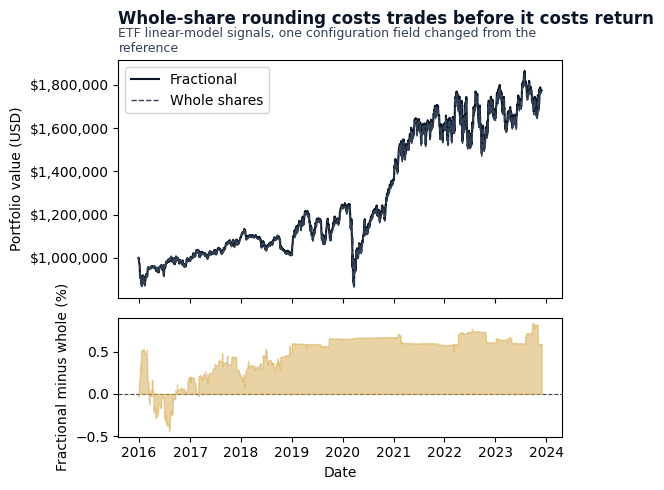

In [13]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], height_ratios=[2, 1], sharex=True)

axes[0].plot(
    eq_base.loc[common_int].index,
    eq_base.loc[common_int].values,
    color=COLORS["blue"],
    label="Fractional",
)
axes[0].plot(
    eq_int.loc[common_int].index,
    eq_int.loc[common_int].values,
    label="Whole shares",
    color=COLORS["neutral"],
    linewidth=1,
    linestyle="--",
)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
add_message_title(
    axes[0],
    "Whole-share rounding costs trades before it costs return",
    subtitle="ETF linear-model signals, one configuration field changed from the reference",
)

axes[1].fill_between(common_int, diff_int.values, alpha=0.5, color=COLORS["amber"])
zero_line(axes[1])
axes[1].set_ylabel("Fractional minus whole (%)")
axes[1].set_xlabel("Date")

fig.tight_layout()
fig.show()

print(
    f"\nFinal value difference: ${val_diff_int:,.0f} ({val_diff_int / r_baseline.final_value:.3%})"
)
print(
    f"Trade count: {r_baseline.n_trades:,} vs {r_integer.n_trades:,} "
    f"(delta: {r_baseline.n_trades - r_integer.n_trades:,})"
)

## 4. Fill ordering, and a setting that never takes effect

A rebalance that both sells and buys has to process one side first, and a long-only account with
no margin cares which. `FillOrdering.EXIT_FIRST` tells the broker to fill sells before buys, so
the proceeds are on hand to spend. `FillOrdering.FIFO` tells it to fill in submission order, so
an early buy can consume cash a later buy needed and the later one is rejected for want of funds.

That is what the setting means. Whether it does anything is a different question, and it has to
be asked before any result is credited to it. Both share types are tested here, because the
obvious reason a fractional run would not care - it never runs out of cash - makes a prediction
about the whole-share run that can be checked.

In [14]:
fifo_config = make_reference()
fifo_config.fill_ordering = FillOrdering.FIFO
r_fifo = run_with_config(fifo_config)

integer_fifo_config = make_reference()
integer_fifo_config.share_type = ShareType.INTEGER
integer_fifo_config.fill_ordering = FillOrdering.FIFO
r_integer_fifo = run_with_config(integer_fifo_config)

table = pl.DataFrame(
    [
        {"config": "Fractional, EXIT_FIRST (reference)", **metrics_row(r_baseline)},
        {"config": "Fractional, FIFO", **metrics_row(r_fifo)},
        {"config": "Whole shares, EXIT_FIRST", **metrics_row(r_integer)},
        {"config": "Whole shares, FIFO", **metrics_row(r_integer_fifo)},
    ]
)
table

config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Fractional, EXIT_FIRST (refere…",1774851,77.49,0.49,30.58,57033,197341
"""Fractional, FIFO""",1774851,77.49,0.49,30.58,57033,197341
"""Whole shares, EXIT_FIRST""",1764302,76.43,0.485,30.59,49543,203501
"""Whole shares, FIFO""",1764302,76.43,0.485,30.59,49543,203501


In [15]:
val_diff = r_baseline.final_value - r_fifo.final_value
integer_val_diff = r_integer.final_value - r_integer_fifo.final_value
ordering_gap_bps = val_diff / r_baseline.final_value * 10_000
integer_ordering_gap_bps = integer_val_diff / r_integer.final_value * 10_000

print(f"Fractional:   EXIT_FIRST minus FIFO = ${val_diff:,.0f} ({ordering_gap_bps:.2f} bps)")
print(
    f"Whole shares: EXIT_FIRST minus FIFO = ${integer_val_diff:,.0f} "
    f"({integer_ordering_gap_bps:.2f} bps)"
)
print(f"Trades, fractional:   {r_baseline.n_trades:,} vs {r_fifo.n_trades:,}")
print(f"Trades, whole shares: {r_integer.n_trades:,} vs {r_integer_fifo.n_trades:,}")

Fractional:   EXIT_FIRST minus FIFO = $0 (0.00 bps)
Whole shares: EXIT_FIRST minus FIFO = $0 (0.00 bps)
Trades, fractional:   57,033 vs 57,033
Trades, whole shares: 49,543 vs 49,543


Both differences are zero, and the second one is what makes this worth a section rather than a
footnote. If the fractional run were unaffected because it never runs out of cash, the
whole-share run - which does have to fit its buys into a finite balance - would differ. It does
not.

The reason sits upstream of the broker. `TargetWeightExecutor` sorts the rebalance itself before
submitting anything: it collects the assets whose exposure is being reduced, submits those, and
only then submits the increases. The comment in `ml4t/backtest/execution/rebalancer.py` calls it
building a deterministic execution order. By the time the broker's queue policy is consulted, the
orders have already arrived sells-first, so both settings describe the same sequence and produce
the same fills.

`FillOrdering` is not dead code. It decides the sequence for a strategy that submits its own
orders in its own order, which is most strategies that are not driven by a target-weight
executor. It is unreachable through this one, and that is the transferable part: a configuration
field is a request, and whether the request reaches the code path you have in mind is a question
with an answer. Change the field, check that something moved, and only then attribute a result to
it. Section 7 shows what a decomposition does when one of its factors is inert.

## 5. The cash a fully invested portfolio does not have

A target row that sums to one asks the account to spend every dollar it holds. The commission is
then due on top, and there is nothing left to pay it with. Some engines - Backtrader among them -
reject the order rather than let the balance go negative, and a rejected order is worse than a
smaller one: the position simply does not move.

The usual workaround scales every target row down by a small factor, so a sliver of cash is
always held back. It is a real fix and it has a real price, because the sliver is not invested.
The multiplier is applied to the whole row, so every held weight keeps its share of the portfolio
and only the total moves; the check that follows confirms the ratio is exact on every active
weight rather than asserting it in prose.

In [16]:
HEADROOM = 0.998
weights_headroom = weights_f * HEADROOM
active_headroom_ratio = weights_headroom.where(weights_f > 0).div(weights_f).stack()
headroom_ratio_error = (active_headroom_ratio - HEADROOM).abs().max()
if headroom_ratio_error > 1e-15:
    raise RuntimeError("Commission headroom is not an exact target-weight multiplier")
headroom_weight_sums = weights_headroom.sum(axis=1)

print(
    f"Target allocation: baseline={baseline_weight_sums.min():.3f}-"
    f"{baseline_weight_sums.max():.3f}, headroom={headroom_weight_sums.min():.3f}-"
    f"{headroom_weight_sums.max():.3f}, active-weight ratio={active_headroom_ratio.min():.3f}"
)

r_headroom = run_with_config(make_reference(), target_weights=weights_headroom)

table = pl.DataFrame(
    [
        {"config": "Full allocation (baseline)", **metrics_row(r_baseline)},
        {"config": f"Headroom multiplier ({HEADROOM})", **metrics_row(r_headroom)},
    ]
)
table

Target allocation: baseline=1.000-1.000, headroom=0.998-0.998, active-weight ratio=0.998


config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Full allocation (baseline)""",1774851,77.49,0.49,30.58,57033,197341
"""Headroom multiplier (0.998)""",1762873,76.29,0.485,30.55,58446,202971



Final value difference: $11,978 (0.675%)


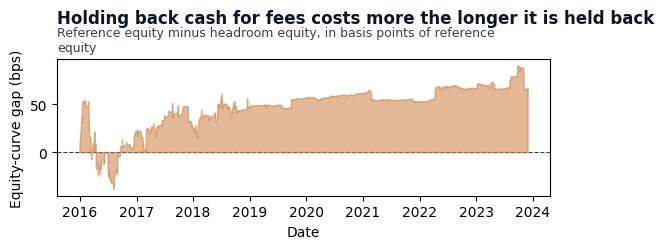

In [17]:
eq_hd = r_headroom.equity_curve
common_hd = eq_base.index.intersection(eq_hd.index)

diff_hd_bps = (eq_base.loc[common_hd] - eq_hd.loc[common_hd]) / eq_base.loc[common_hd] * 10_000
val_diff_hd = r_baseline.final_value - r_headroom.final_value
headroom_gap_bps = val_diff_hd / r_baseline.final_value * 10_000

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.fill_between(common_hd, diff_hd_bps.values, alpha=0.5, color=COLORS["copper"])
zero_line(ax)
ax.set_ylabel("Equity-curve gap (bps)")
ax.set_xlabel("Date")
add_message_title(
    ax,
    "Holding back cash for fees costs more the longer it is held back",
    subtitle="Reference equity minus headroom equity, in basis points of reference equity",
)
fig.tight_layout()
fig.show()

print(f"\nFinal value difference: ${val_diff_hd:,.0f} ({val_diff_hd / r_baseline.final_value:.3%})")

The drag is not the size of the buffer. A portfolio permanently short a fraction of its exposure
gives up that fraction of every subsequent return, and those givings-up compound, so the cost over
eight years is larger than the buffer and depends on what the market did in between. Reading the
gap as "the buffer costs the buffer" understates it.

The buffer is also not optional for the engines that need it. What it is, is a cost that belongs
on the engine's side of a comparison rather than the strategy's.

## 6. The same choices, bundled the way real engines bundle them

The sections above changed one field at a time, which is how you learn what a field does and not
how anyone actually runs a backtest. A library ships a bundle: Backtrader gives you whole shares,
submission-order fills and a cash constraint that forces a buffer; a vectorized library gives you
fractional positions and, unless told otherwise, fills at the same close it read.

`BacktestConfig` has presets for both bundles, which means the same engine can be asked to
imitate either. The fourth row runs the real VectorBT on identical filtered prices and weights,
which is the check that the imitation is worth anything.

| Profile | Fill timing | Shares | Fill order | Cash buffer |
|---|---|---|---|---|
| Controlled reference | Next bar's open | Fractional | Exits first | None |
| `backtrader` preset | Next bar's open | Whole | Submission order | Yes |
| `vectorbt` preset | Same bar's close | Fractional | Exits first | None |
| VectorBT itself | Same bar's close | Fractional | Its own | None |


In [18]:
# Backtrader preset
bt_config = BacktestConfig.from_preset("backtrader")
bt_config.initial_cash = INITIAL_CASH
bt_config.commission_rate = cost_rate
bt_config.slippage_type = SlippageType.NONE
bt_config.slippage_rate = 0.0

r_bt = run_with_config(bt_config, target_weights=weights_headroom)

# VectorBT preset (ml4t engine matching VBT behavior)
vbt_config = BacktestConfig.from_preset("vectorbt")
vbt_config.initial_cash = INITIAL_CASH
vbt_config.commission_type = CommissionType.PERCENTAGE
vbt_config.commission_rate = cost_rate
vbt_config.slippage_type = SlippageType.NONE
vbt_config.slippage_rate = 0.0

r_vbt_preset = run_with_config(vbt_config)

In [19]:
# Actual VectorBT engine
r_vbt = run_vectorbt(prices_f, weights_f, initial_cash=INITIAL_CASH, commission_rate=cost_rate)
all_results = [r_baseline, r_bt, r_vbt_preset, r_vbt]
all_labels = ["controlled reference", "backtrader profile", "vectorbt profile", "VectorBT"]
styles = [
    {"color": COLORS["blue"], "linewidth": 1.8},
    {"color": COLORS["neutral"], "linestyle": "--"},
    {"color": COLORS["amber"], "linestyle": "-."},
    {"color": COLORS["copper"], "linestyle": ":"},
]

In [20]:
table = pl.DataFrame(
    [{"config": label, **metrics_row(r)} for r, label in zip(all_results, all_labels, strict=True)]
)
table

config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""controlled reference""",1774851,77.49,0.49,30.58,57033,197341
"""backtrader profile""",1761784,76.18,0.485,30.56,50136,203441
"""vectorbt profile""",1797525,79.93,0.499,30.34,58180,206675
"""VectorBT""",1835158,83.7,0.516,30.35,54971,190230


Spread between the highest and lowest profile: 4.00% of final value


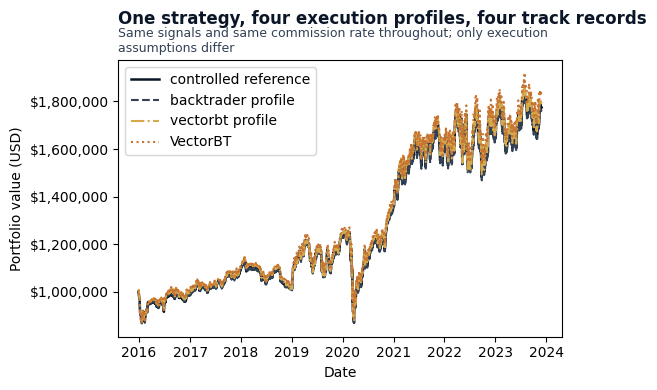

In [21]:
profile_values = [r.final_value for r in all_results]
profile_spread_pct = (max(profile_values) - min(profile_values)) / max(profile_values) * 100
print(f"Spread between the highest and lowest profile: {profile_spread_pct:.2f}% of final value")

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
for r, label, style in zip(all_results, all_labels, styles, strict=True):
    ax.plot(r.equity_curve.index, r.equity_curve.values, label=label, **style)

ax.set_ylabel("Portfolio value (USD)")
ax.set_xlabel("Date")
add_message_title(
    ax,
    "One strategy, four execution profiles, four track records",
    subtitle="Same signals and same commission rate throughout; only execution assumptions differ",
)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
fig.tight_layout()
fig.show()

Two of these four fill at the same close the signal was read from, which is not a chronology any
account can trade: the closing price is not known until after the order would have had to exist.
Their curves are higher for that reason and are not comparable with the two that fill at the next
open. Read them as a measurement of what same-bar filling is worth, which is the number a reader
needs in order to reject a backtest that does it.

The gap between the `vectorbt` preset and VectorBT itself is the honest residual of this exercise:
two engines configured to agree, still not agreeing, because a preset can only name the
assumptions somebody thought to expose.

## 7. A decomposition that does not add up

The Backtrader profile differs from the reference in three named ways at once. Each of those was
measured on its own above, so the obvious move is to add the three and check the total against
the profile-versus-reference gap.

It will not match, and the mismatch is the useful part. Two of the three change what the account
holds, which changes what the next rebalance has to trade, which changes what the third one does.
Effects that alter each other's inputs do not add. The residual is not an error term to apologise
for; it is the size of the interaction, and reporting it is what stops a reader from taking any
single bar as that lever's contribution to the bundle.

In [22]:
# Compute individual effects as percentage of baseline final value
baseline_val = r_baseline.final_value
effects = {
    "Fill ordering\n(EXIT_FIRST → FIFO)": (r_baseline.final_value - r_fifo.final_value)
    / baseline_val
    * 100,
    "Share rounding\n(fractional → whole)": (r_baseline.final_value - r_integer.final_value)
    / baseline_val
    * 100,
    "Commission headroom\n(100% → 99.8%)": (r_baseline.final_value - r_headroom.final_value)
    / baseline_val
    * 100,
}

# Combined: controlled reference vs Backtrader profile
combined = (r_baseline.final_value - r_bt.final_value) / baseline_val * 100

labels = list(effects.keys()) + ["Combined\n(reference to Backtrader)"]
values = list(effects.values()) + [combined]
colors = [COLORS["blue"]] * 3 + [COLORS["slate"]]

A horizontal bar chart separates the three one-factor effects from their
combined profile; the interaction is computed immediately afterward.

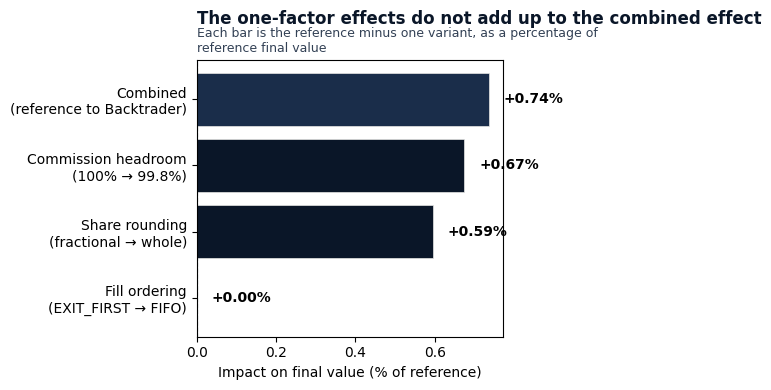

In [23]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
bars = ax.barh(labels, values, color=colors, edgecolor=COLORS["silver_muted"], linewidth=0.5)

# Value labels on bars
for bar, val in zip(bars, values, strict=True):
    x = bar.get_width()
    ax.text(
        x + 0.05 * max(abs(v) for v in values),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.2f}%",
        va="center",
        fontweight="bold",
    )

ax.set_xlabel("Impact on final value (% of reference)")
add_message_title(
    ax,
    "The one-factor effects do not add up to the combined effect",
    subtitle="Each bar is the reference minus one variant, as a percentage of reference final value",
)
zero_line(ax, axis="x")
fig.tight_layout()
fig.show()

In [24]:
sum_individual = sum(effects.values())
interaction = combined - sum_individual

print(f"Individual effects sum: {sum_individual:+.2f}%")
print(f"Combined effect:        {combined:+.2f}%")
print(f"Interaction term:       {interaction:+.2f}%")

Individual effects sum: +1.27%
Combined effect:        +0.74%
Interaction term:       -0.53%


One of the three bars is exactly zero, and section 4 established why: the executor sorts the
rebalance before the broker's queue policy sees it, so changing that policy changes nothing. A
decomposition with an inert factor still adds up correctly - zero adds to anything - but it
invites a reader to conclude that fill ordering was tested and found small. It was not tested. It
was unreachable. The difference matters for anyone porting this strategy to an engine whose
executor does not sort, where the same field is live.

## 8. Rebalance mode: what a multi-asset rebalance knows while it runs

Rebalancing a hundred positions is not one decision, it is a hundred orders, and the engine has
to say what each one knows. Does order fifty size itself against the portfolio value as it stood
before any of this started, or against the value after the first forty-nine have filled and moved
the cash balance?

The two answers correspond to real broker behaviour rather than to implementation taste, and a
third splits the difference:

| Mode | Target value | Fills | Resembles |
|---|---|---|---|
| Snapshot | Computed once, before anything fills | All submitted, then processed | Backtrader, Zipline |
| Incremental | Recomputed after every fill | One at a time | A broker that re-checks the account each time |
| Hybrid | Computed once | One at a time, cash checked live | VectorBT |

`BacktestConfig.rebalance_mode` names the choice instead of burying it.

The three runs below share a configuration that is deliberately not the reference: whole shares,
submission-order fills, same-bar close execution and the cash buffer. That combination is the one
in which rebalance mode has anything to bite on, because a fractional account with next-open
fills never runs low on cash mid-rebalance. Only the mode changes between the three.

In [25]:
def run_rebalance_mode(mode: RebalanceMode):
    """Run one rebalance mode under a fixed whole-share, same-bar-close, buffered profile."""
    config = make_reference()
    config.share_type = ShareType.INTEGER
    config.fill_ordering = FillOrdering.FIFO
    config.execution_mode = ExecutionMode.SAME_BAR
    config.execution_price = ExecutionPrice.CLOSE
    config.rebalance_mode = mode

    rebal_cfg = RebalanceConfig(
        allow_fractional=False,
        min_trade_value=0.0,
        min_weight_change=0.0,
        rebalance_mode=mode,
    )

    weight_dict: dict = {}
    for ts in weights_f.index:
        ts_dt = ts.to_pydatetime() if hasattr(ts, "to_pydatetime") else ts
        row = weights_headroom.loc[ts]
        w = {c: float(row[c]) for c in sorted(weights_headroom.columns) if row[c] > 0}
        if w:
            weight_dict[ts_dt] = w

    executor = TargetWeightExecutor(config=rebal_cfg)
    strategy = PrecomputedWeightStrategy(weight_dict, executor)
    feed = DataFeed(prices_df=prices_f)
    engine = Engine.from_config(feed, strategy, copy.deepcopy(config))
    result = engine.run()
    return _convert_result(result, mode.value, config.initial_cash)


r_snapshot = run_rebalance_mode(RebalanceMode.SNAPSHOT)
r_incremental = run_rebalance_mode(RebalanceMode.INCREMENTAL)
r_hybrid = run_rebalance_mode(RebalanceMode.HYBRID)

In [26]:
table = pl.DataFrame(
    [
        {"mode": "Snapshot (Backtrader-style)", **metrics_row(r_snapshot)},
        {"mode": "Incremental (live value)", **metrics_row(r_incremental)},
        {"mode": "Hybrid (VectorBT-style)", **metrics_row(r_hybrid)},
    ]
)
table

mode,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Snapshot (Backtrader-style)""",1795486,79.73,0.499,30.29,50237,206362
"""Incremental (live value)""",1795691,79.75,0.499,30.29,50107,206282
"""Hybrid (VectorBT-style)""",1795486,79.73,0.499,30.29,50237,206362


In [27]:
eq_snap = r_snapshot.equity_curve
eq_incr = r_incremental.equity_curve
eq_hybr = r_hybrid.equity_curve
common_rb = eq_snap.index.intersection(eq_incr.index).intersection(eq_hybr.index)
rebalance_values = [r_snapshot.final_value, r_incremental.final_value, r_hybrid.final_value]
rebalance_spread_bps = (
    (max(rebalance_values) - min(rebalance_values)) / max(rebalance_values) * 10_000
)
print(f"Spread across the three rebalance modes: {rebalance_spread_bps:.1f} bps of final value")

Spread across the three rebalance modes: 1.1 bps of final value


The upper panel compares the three value paths. The lower panel magnifies the
incremental-minus-snapshot gap on the same dates.

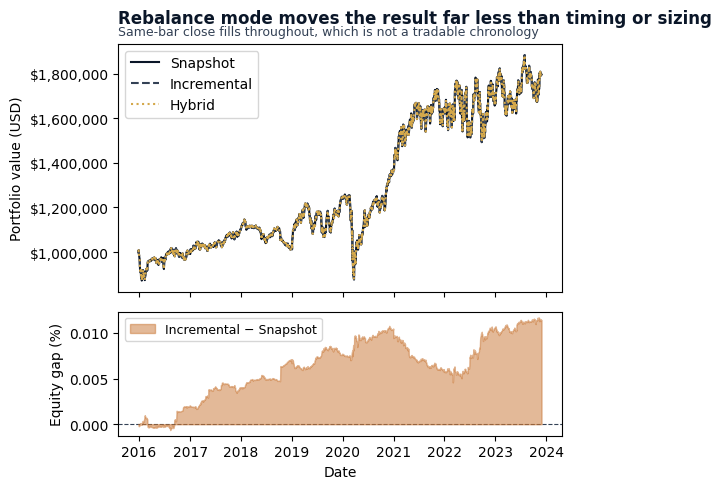

In [28]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], height_ratios=[2, 1], sharex=True)

axes[0].plot(common_rb, eq_snap.loc[common_rb].values, color=COLORS["blue"], label="Snapshot")
axes[0].plot(
    common_rb,
    eq_incr.loc[common_rb].values,
    color=COLORS["neutral"],
    label="Incremental",
    linestyle="--",
)
axes[0].plot(
    common_rb,
    eq_hybr.loc[common_rb].values,
    color=COLORS["amber"],
    label="Hybrid",
    linestyle=":",
)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
add_message_title(
    axes[0],
    "Rebalance mode moves the result far less than timing or sizing",
    subtitle="Same-bar close fills throughout, which is not a tradable chronology",
)

# Show incremental vs snapshot divergence
diff_is = (eq_incr.loc[common_rb] - eq_snap.loc[common_rb]) / eq_snap.loc[common_rb] * 100
axes[1].fill_between(
    common_rb, diff_is.values, alpha=0.5, color=COLORS["copper"], label="Incremental − Snapshot"
)
zero_line(axes[1])
axes[1].set_ylabel("Equity gap (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.show()

The three curves are close together and all three are wrong in the same way. The weights were
computed from day $t$'s close and filled at day $t$'s close, which no account can do: the price
is not known until after the order would have had to be placed. Nothing in this section is
strategy performance, and the highest of the three curves does not identify a better mode.

What holding an untradable chronology fixed does buy is a clean read on the modes themselves,
because whatever the same-bar fill is worth, it is worth the same to all three. The answer is
that this choice is worth far less than the ones in sections 3 and 5 - which is itself the
finding, and the reason to spend attention on fill timing and sizing first.

## Key takeaways

1. **Validity comes before size.** A signal read from the close cannot be filled at that close,
   and no rebalance mode, cost model or sizing rule repairs that. Settle the order of decision,
   submission and fill first; only then is it meaningful to ask what anything is worth.
2. **Check that a setting is reachable before you credit it.** Fill ordering measured exactly zero
   here, in both share regimes, because the target-weight executor sorts the rebalance before the
   broker's queue policy is consulted. A field you can set is not necessarily a field that acts.
   Change it, confirm something moved, then attribute.
3. **Whole-share rounding shows up in the trade count first.** An order that rounds to zero shares
   is never submitted, so the position stops tracking its target. That effect does not shrink with
   account size the way the rounding error does.
4. **Cash held back to pay fees is exposure given up on every subsequent day.** The drag
   compounds and is larger than the buffer itself. Charge it against the engine that requires the
   buffer, not against the strategy.
5. **One-factor effects do not add.** When two levers change what the account holds, each changes
   what the other has to trade. Measure the bundle as well as the parts, and report the residual
   as a quantity.
6. **Set every execution field explicitly, including the ones that match the default.** A preset
   is a moving target. An experiment that inherits one silently changes when the library does, and
   nothing in the notebook records that it happened.
7. **Publish the assumptions with the result.** Fill timing, share type, fill ordering, rebalance
   mode and cost model. A backtest without them is not reproducible by anyone, including its
   author six months later.

### Known limitations

- The signals come from one case study's linear model over one validation window. The size of
  every effect here depends on that strategy's turnover, and a slower strategy would trade fewer
  times and pay less for all of it.
- Effects are measured one at a time against a single reference. That answers "what does this
  field do to this configuration", not "what is this field worth in general", and the interaction
  term in section 7 is how much the difference matters here.
- Slippage is switched off throughout, so nothing below measures how execution choices interact
  with a price that moves against the order. Chapter 18 puts a cost model behind the fill.
- Section 8 runs on an untradable chronology by design, and its numbers are not returns.

**Next:** the external-engine parity notebooks put the same fields against real engines on the
canonical benchmark: [`15_lean_engine_parity`](15_lean_engine_parity.ipynb),
[`17_backtrader_zipline_engine_parity`](17_backtrader_zipline_engine_parity.ipynb) and
[`18_vectorbt_engine_parity`](18_vectorbt_engine_parity.ipynb). Section 16.3 covers configurable
parity and framework validation.